In [1]:
import pandas as pd
import numpy as np
import torch.nn as nn
import torchvision
from torchvision.datasets import CIFAR10
from torchvision.transforms import transforms

In [20]:
transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

trainset = CIFAR10(root='./data', train=True, transform=transform)
testset = CIFAR10(root='./data', train=False, transform=transform)

d:\Deep-Learning-Foundations\venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


In [21]:
from torch.utils.data import DataLoader

train_loader = DataLoader(dataset=trainset, shuffle=True, batch_size=64)
test_loader = DataLoader(dataset=testset, batch_size=64)

In [22]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()

        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
        )

        self.fully_conn_layer = nn.Sequential(
            nn.Linear(4*4*128, 256),
            nn.ReLU(),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = x.view(x.size(0), -1)
        x = self.fully_conn_layer(x)
        return x
        

In [23]:
model = CNN()

In [24]:
from torch.optim import Adam

criterion = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters())

In [25]:
import torch

epochs = 10
best_epoch = 0
lowest_loss = float('inf')
training_losses = []
validation_losses = []

for epoch in range(epochs):

    model.train()
    running_training_loss = 0.0
    validation_running_loss = 0.0

    for images, labels in train_loader:

        optimizer.zero_grad()
        outputs = model.forward(images)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_training_loss += loss.item()

    epoch_running_loss = running_training_loss / len(train_loader)
    training_losses.append(epoch_running_loss)

    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:

            outputs = model.forward(images)
            loss = criterion(outputs, labels)
            validation_running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            correct += (predicted == labels).sum().item()
            total += labels.size(0)
        
        epoch_running_loss = validation_running_loss / len(test_loader)
        validation_losses.append(epoch_running_loss)
        accuracy = correct / total * 100
        print(f'loss = {epoch_running_loss} for epoch = {epoch+1}')

        if epoch_running_loss < lowest_loss :
            lowest_loss = epoch_running_loss
            best_epoch = epoch + 1
            torch.save(model.state_dict(), 'best_model.pt')

        print(f'accuracy for epoch {epoch+1} : {accuracy}\n')

print(f'lowest loss of {lowest_loss} was achieved at epoch = {best_epoch}')

loss = 1.2972715424883896 for epoch = 1
accuracy for epoch 1 : 53.03

loss = 1.0780783420915057 for epoch = 2
accuracy for epoch 2 : 61.38

loss = 0.9902624840948991 for epoch = 3
accuracy for epoch 3 : 65.03

loss = 0.8887882559162796 for epoch = 4
accuracy for epoch 4 : 68.56

loss = 0.9053381594123354 for epoch = 5
accuracy for epoch 5 : 68.23

loss = 0.7773985513456309 for epoch = 6
accuracy for epoch 6 : 72.28

loss = 0.7653289839720271 for epoch = 7
accuracy for epoch 7 : 73.34

loss = 0.7238143532519128 for epoch = 8
accuracy for epoch 8 : 75.05

loss = 0.748431156585171 for epoch = 9
accuracy for epoch 9 : 73.33

loss = 0.7133394578459916 for epoch = 10
accuracy for epoch 10 : 74.89

lowest loss of 0.7133394578459916 was achieved at epoch = 10


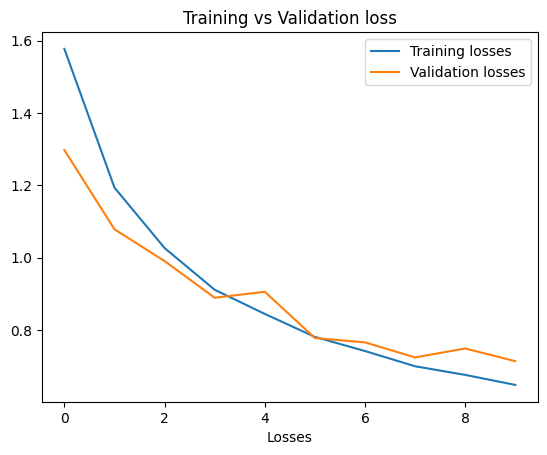

In [26]:
import matplotlib.pyplot as plt

loss_df = pd.DataFrame({
    'Training losses' : training_losses,
    'Validation losses' : validation_losses
})

plt.plot(loss_df['Training losses'], label = 'Training losses')
plt.plot(loss_df['Validation losses'], label = 'Validation losses')

plt.xlabel('Epochs')
plt.xlabel('Losses')

plt.title("Training vs Validation loss")

plt.legend()

In [27]:
model.load_state_dict(torch.load('best_model.pt'))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

In [28]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy:", accuracy_score(all_labels, all_preds))
print("Precision:", precision_score(all_labels, all_preds, average='weighted'))
print("Recall:", recall_score(all_labels, all_preds, average='weighted'))
print("F1 Score:", f1_score(all_labels, all_preds, average='weighted'))

Accuracy: 0.7504
Precision: 0.7567630064045688
Recall: 0.7504
F1 Score: 0.7486849209914312


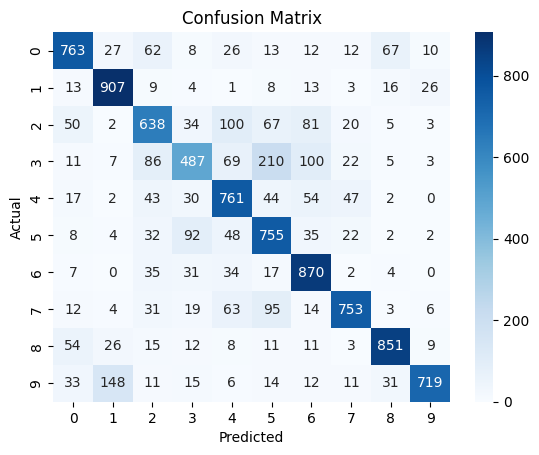

In [29]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(all_labels, all_preds)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

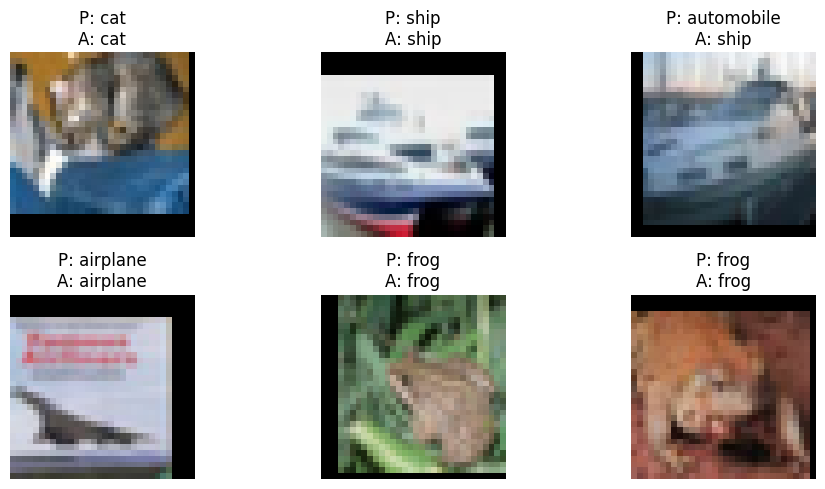

In [30]:
classes = trainset.classes

images, labels = next(iter(test_loader))
outputs = model(images)
_, preds = torch.max(outputs, 1)

plt.figure(figsize=(10,5))

for i in range(6):
    plt.subplot(2,3,i+1)
    
    img = images[i].permute(1,2,0)
    img = img * 0.5 + 0.5  # unnormalize
    
    plt.imshow(img)
    plt.title(f"P: {classes[preds[i]]}\nA: {classes[labels[i]]}")
    plt.axis("off")

plt.tight_layout()
plt.show()